In [1]:
"""
Unified EOS Analysis Tool.
1. plot_eos_curves(*args) -> Plots spaghetti curves.
2. compare_eos_results(*args) -> Plots histograms.

Args can be:
- "path/to/file.h5" (No filter)
- ("path/to/file.h5", {'param': (min, max)}) (With filter)
"""

import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import logging
from matplotlib.collections import LineCollection
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import jax

# --- JesterTOV Imports ---
jax.config.update("jax_platforms", "cpu")
try:
    from jesterTOV import utils
except ImportError:

    class utils:
        fm_inv3_to_SI = 1e45
        geometric_to_MeV_fm_inv3 = 1.0


# ==============================================================================
#                               MASTER CONFIGURATION
# ==============================================================================

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("eos_master")

PLOT_CONFIG = {
    "DPI": 150,
    "USE_TEX": True,
    "FIG_SIZE": (14, 6),
    "NUM_SAMPLES": 500,
    "ALPHA": 0.15,
    "LINEWIDTH": 1.0,
    "FIG_WIDTH": 16,
    "COLS": 4,
    "BINS": 40,
}

try:
    CURRENT_DIR = Path(__file__).resolve().parent
except NameError:
    CURRENT_DIR = Path.cwd()

ROOT_JESTER = CURRENT_DIR.parents[1]
BASE_PATH = ROOT_JESTER / "jesterTOV" / "inference"

CHIEFT_CONFIG = {
    "DATA_DIR": BASE_PATH / "data" / "chiEFT" / "2402.04172",
    "LOW_FILE": "low.dat",
    "HIGH_FILE": "high.dat",
    "COLOR": "gray",
    "ALPHA": 0.7,
    "ZORDER": 0,
}

N_SAT_FM = 0.16
N_SAT_SI = N_SAT_FM * utils.fm_inv3_to_SI
GEOM_TO_MEVFM3 = utils.geometric_to_MeV_fm_inv3


def setup_matplotlib():
    plt.rcParams.update(
        {
            "axes.grid": True,
            "grid.alpha": 0.3,
            "axes.labelsize": 14,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "legend.fontsize": 12,
            "figure.titlesize": 16,
            "mathtext.fontset": "cm",
            "font.family": "serif",
        }
    )
    if PLOT_CONFIG["USE_TEX"]:
        try:
            from matplotlib.checkdep_usetex import checkdep_usetex

            if checkdep_usetex(True):
                plt.rcParams.update({"text.usetex": True})
        except:
            pass


# ==============================================================================
#                                DATA LOADING
# ==============================================================================


def load_h5_data(filepath, mode="curves", filters=None):
    """
    Robust loader that handles ragged arrays and filtering.
    """
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None

    with h5py.File(filepath, "r") as f:
        if "posterior" not in f:
            return None
        post = f["posterior"]

        # --- 1. DETERMINE REFERENCE LENGTH ---
        n_samples = 0
        ref_param = None

        # If filtering, the filter param dictates the length
        if filters and "parameters" in post:
            for k in filters.keys():
                if k in post["parameters"]:
                    n_samples = post["parameters"][k].shape[0]
                    ref_param = k
                    break

        # Fallback length detection
        if n_samples == 0:
            if "parameters" in post:
                ref_param = list(post["parameters"].keys())[0]
                n_samples = post["parameters"][ref_param].shape[0]
            elif "derived_eos" in post:
                grp = post["derived_eos"]
                k = "masses_EOS" if "masses_EOS" in grp else "masses"
                n_samples = grp[k].shape[0]

        if n_samples == 0:
            return None

        # --- 2. GENERATE MASK ---
        mask = np.ones(n_samples, dtype=bool)

        if filters and "parameters" in post:
            for param, bounds in filters.items():
                if param in post["parameters"]:
                    dset = post["parameters"][param]
                    # SAFETY: Check length before masking
                    if dset.shape[0] != n_samples:
                        logger.warning(
                            f"   ⚠️ Skipping filter '{param}': length mismatch."
                        )
                        continue

                    data_vec = dset[:]
                    mask = mask & ((data_vec >= bounds[0]) & (data_vec <= bounds[1]))
                    logger.info(
                        f"   Refining [{os.path.basename(filepath)}] filter '{param}': kept {np.sum(mask)}/{n_samples}"
                    )

        if np.sum(mask) == 0:
            logger.warning(
                f"   ❌ All data filtered out for {os.path.basename(filepath)}"
            )
            return None

        # --- MODE: CURVES ---
        if mode == "curves":
            group = post.get("derived_eos", post)
            if "masses" not in group and "masses_EOS" not in group:
                return None
            try:
                m = group.get("masses_EOS", group.get("masses"))[:]
                r = group.get("radii_EOS", group.get("radii"))[:]
                n = group.get("n")[:] / N_SAT_SI
                p = group.get("p")[:] * GEOM_TO_MEVFM3

                # Align with n_samples
                if len(m) > n_samples:
                    m, r, n, p = (
                        m[:n_samples],
                        r[:n_samples],
                        n[:n_samples],
                        p[:n_samples],
                    )
                elif len(m) < n_samples:
                    return None  # Cannot safely mask

                final_m, final_r, final_n, final_p = [], [], [], []
                indices = np.where(mask)[0]
                for i in indices:
                    if len(m[i]) > 1:
                        final_m.append(m[i])
                        final_r.append(r[i])
                        final_n.append(n[i])
                        final_p.append(p[i])

                if not final_m:
                    return None
                return {"m": final_m, "r": final_r, "n": final_n, "p": final_p}
            except Exception as e:
                logger.error(f"Failed to read curves: {e}")
                return None

        # --- MODE: PARAMS ---
        elif mode == "params":
            data = {}
            if "parameters" in post:
                for k in post["parameters"].keys():
                    dset = post["parameters"][k]
                    if dset.shape[0] == n_samples:
                        data[k] = dset[:][mask]

            eos_group = post.get("derived_eos", post)

            def add_derived(name, arr):
                if len(arr) >= n_samples:
                    data[name] = arr[:n_samples][mask]

            if "M_TOV" not in data:
                try:
                    masses = eos_group.get("masses_EOS", eos_group.get("masses"))[:]
                    if len(masses) >= n_samples:
                        m_tov = np.array(
                            [np.max(m) if len(m) > 0 else 0 for m in masses]
                        )
                        add_derived("M_TOV", m_tov)
                except:
                    pass

            if "R_1.4" not in data:
                try:
                    masses = eos_group.get("masses_EOS", eos_group.get("masses"))[:]
                    radii = eos_group.get("radii_EOS", eos_group.get("radii"))[:]
                    if len(masses) >= n_samples:
                        r14 = []
                        for i in range(len(masses)):
                            m, r = masses[i], radii[i]
                            if len(m) > 1:
                                srt = np.argsort(m)
                                r14.append(np.interp(1.4, m[srt], r[srt]))
                            else:
                                r14.append(np.nan)
                        add_derived("R_1.4", np.array(r14))
                except:
                    pass
            return data
    return None


def get_segments(x_data, y_data, n_samples):
    """Helper for LineCollection."""
    total = len(x_data)
    if total == 0:
        return []
    N = min(total, n_samples)
    indices = np.random.choice(total, N, replace=False)
    segments = []
    for i in indices:
        x, y = x_data[i], y_data[i]
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
        if np.sum(mask) > 1:
            segments.append(np.column_stack([x[mask], y[mask]]))
    return segments


def get_fancy_label(name):
    MAPPING = {
        "M_TOV": r"$M_{\rm{TOV}}$ $[M_{\odot}]$",
        "R_1.4": r"$R_{1.4}$ [km]",
        "P_3nsat": r"$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]",
        "L_sym": r"$L_{\rm{sym}}$",
        "K_sat": r"$K_{\rm{sat}}$",
        "chi2": r"$\chi^2$",
        "log_prob": r"$\ln \mathcal{L}$",
    }
    if name in MAPPING:
        return MAPPING[name]
    parts = name.split("_")
    base = parts[0]
    if base in [
        "alpha",
        "beta",
        "gamma",
        "delta",
        "rho",
        "sigma",
        "kappa",
        "lambda",
        "epsilon",
    ]:
        base = f"\\{base}"
    if len(parts) > 1:
        return f"${base}_{{{r'\_'.join(parts[1:])}}}$"
    return f"${base}$"


# ==============================================================================
#                               PLOT FUNCTION 1: CURVES
# ==============================================================================


def plot_eos_curves(*args, labels=None):
    """
    Plots EOS/MR curves.
    Input: "file.h5" OR ("file.h5", filter_dict)
    """
    setup_matplotlib()
    datasets, valid_paths = [], []

    logger.info(f"⏳ [Curves] Processing {len(args)} inputs...")

    for item in args:
        # Parse Input: Tuple or String?
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None

        d = load_h5_data(fpath, mode="curves", filters=f_dict)
        if d:
            datasets.append(d)
            valid_paths.append(fpath)

    if not datasets:
        logger.error("No data found or all filtered out.")
        return

    if not labels:
        labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets):
        labels += [os.path.basename(p) for p in valid_paths[len(labels) :]]

    colors = (
        plt.cm.tab10(np.linspace(0, 1, 10))
        if len(datasets) <= 10
        else plt.cm.turbo(np.linspace(0, 1, len(datasets)))
    )

    fig, (ax_eos, ax_mr) = plt.subplots(
        1, 2, figsize=PLOT_CONFIG["FIG_SIZE"], dpi=PLOT_CONFIG["DPI"]
    )

    # Background: ChiEFT
    try:
        low_path = CHIEFT_CONFIG["DATA_DIR"] / CHIEFT_CONFIG["LOW_FILE"]
        high_path = CHIEFT_CONFIG["DATA_DIR"] / CHIEFT_CONFIG["HIGH_FILE"]
        if low_path.exists() and high_path.exists():
            low = np.loadtxt(low_path)
            high = np.loadtxt(high_path)
            min_len = min(len(low), len(high))
            ax_eos.fill_between(
                low[:min_len, 0] / N_SAT_FM,
                low[:min_len, 1],
                high[:min_len, 1],
                color=CHIEFT_CONFIG["COLOR"],
                alpha=CHIEFT_CONFIG["ALPHA"],
                zorder=0,
                label="ChiEFT",
            )
    except:
        pass

    # Foreground
    for i, data in enumerate(datasets):
        c, lbl = colors[i], labels[i]

        segs = get_segments(data["n"], data["p"], PLOT_CONFIG["NUM_SAMPLES"])
        if segs:
            ax_eos.add_collection(
                LineCollection(
                    segs,
                    colors=c,
                    alpha=PLOT_CONFIG["ALPHA"],
                    linewidths=PLOT_CONFIG["LINEWIDTH"],
                )
            )
            ax_eos.plot([], [], color=c, label=lbl, lw=2)

        segs_mr = get_segments(data["r"], data["m"], PLOT_CONFIG["NUM_SAMPLES"])
        if segs_mr:
            ax_mr.add_collection(
                LineCollection(
                    segs_mr,
                    colors=c,
                    alpha=PLOT_CONFIG["ALPHA"],
                    linewidths=PLOT_CONFIG["LINEWIDTH"],
                )
            )

    ax_eos.set_xscale("log")
    ax_eos.set_yscale("log")
    ax_eos.set_xlim(3e-1, 2.5)
    ax_eos.set_ylim(1e-1, 30)
    ax_eos.set_xlabel(r"$n/n_{\rm{sat}}$")
    ax_eos.set_ylabel(r"$P$ [MeV fm$^{-3}$]")
    ax_eos.legend(loc="upper left")

    ax_mr.set_xlim(8, 18)
    ax_mr.set_ylim(0.5, 3.0)
    ax_mr.set_xlabel(r"$R$ [km]")
    ax_mr.set_ylabel(r"$M$ $[M_{\odot}]$")
    plt.tight_layout()
    plt.show()


# ==============================================================================
#                               PLOT FUNCTION 2: HISTOGRAMS
# ==============================================================================


def compare_eos_results(*args, labels=None):
    """
    Plots histograms.
    Input: "file.h5" OR ("file.h5", filter_dict)
    """
    setup_matplotlib()
    datasets, valid_paths = [], []

    logger.info(f"⏳ [Histograms] Processing {len(args)} inputs...")

    for item in args:
        # Parse Input: Tuple or String?
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None

        d = load_h5_data(fpath, mode="params", filters=f_dict)
        if d:
            datasets.append(d)
            valid_paths.append(fpath)

    if not datasets:
        logger.error("No data found or all filtered out.")
        return

    if not labels:
        labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets):
        labels += [os.path.basename(p) for p in valid_paths[len(labels) :]]

    colors = (
        plt.cm.tab10(np.linspace(0, 1, 10))
        if len(datasets) <= 10
        else plt.cm.turbo(np.linspace(0, 1, len(datasets)))
    )

    all_keys = sorted(list(set().union(*(d.keys() for d in datasets))))
    valid_keys = [
        k
        for k in all_keys
        if any(k in d and d[k].ndim == 1 and np.std(d[k]) > 1e-12 for d in datasets)
    ]

    if not valid_keys:
        return

    n_plots = len(valid_keys)
    cols = PLOT_CONFIG["COLS"]
    rows = (n_plots + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(PLOT_CONFIG["FIG_WIDTH"], rows * 3.5),
        dpi=PLOT_CONFIG["DPI"],
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, param in enumerate(valid_keys):
        ax = axes[i]
        for j, data in enumerate(datasets):
            if param in data:
                d = data[param][np.isfinite(data[param])]
                if len(d) == 0:
                    continue

                lbl = labels[j] if i == 0 else ""
                ax.hist(
                    d,
                    bins=PLOT_CONFIG["BINS"],
                    density=True,
                    color=colors[j],
                    alpha=0.3,
                    label=lbl,
                )
                ax.hist(
                    d,
                    bins=PLOT_CONFIG["BINS"],
                    density=True,
                    color=colors[j],
                    histtype="step",
                    linewidth=1.5,
                )
                ax.axvline(np.median(d), color=colors[j], linestyle="--", alpha=0.8)

        ax.set_title(get_fancy_label(param))
        ax.set_yticks([])
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    fig.legend(
        loc="upper center",
        ncol=min(len(datasets), 5),
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )
    plt.tight_layout()
    plt.show()

⏳ [Curves] Processing 1 inputs...


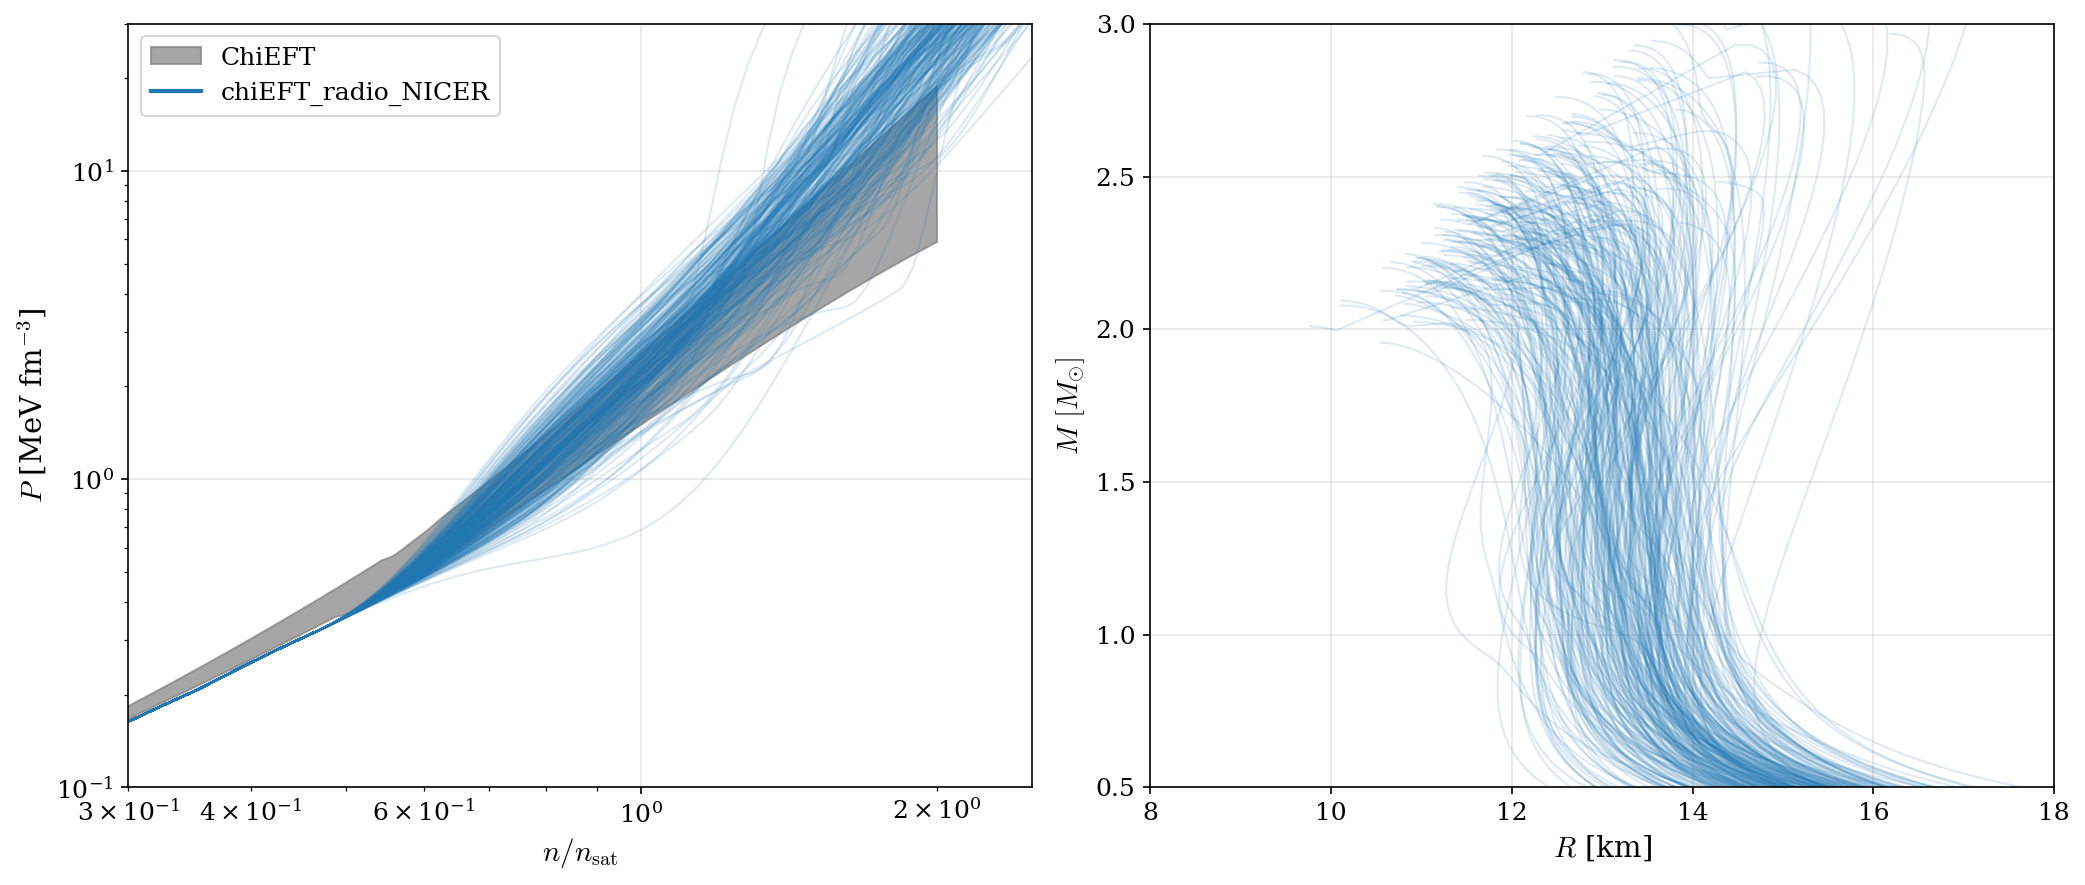

In [2]:
files_to_compare = [
    "st_smc_random_walk/chiEFT_radio_NICER/outdir/results.h5",
]

my_labels = [
    "chiEFT_radio_NICER",
]

plot_eos_curves(*files_to_compare, labels=my_labels)

⏳ [Histograms] Processing 1 inputs...


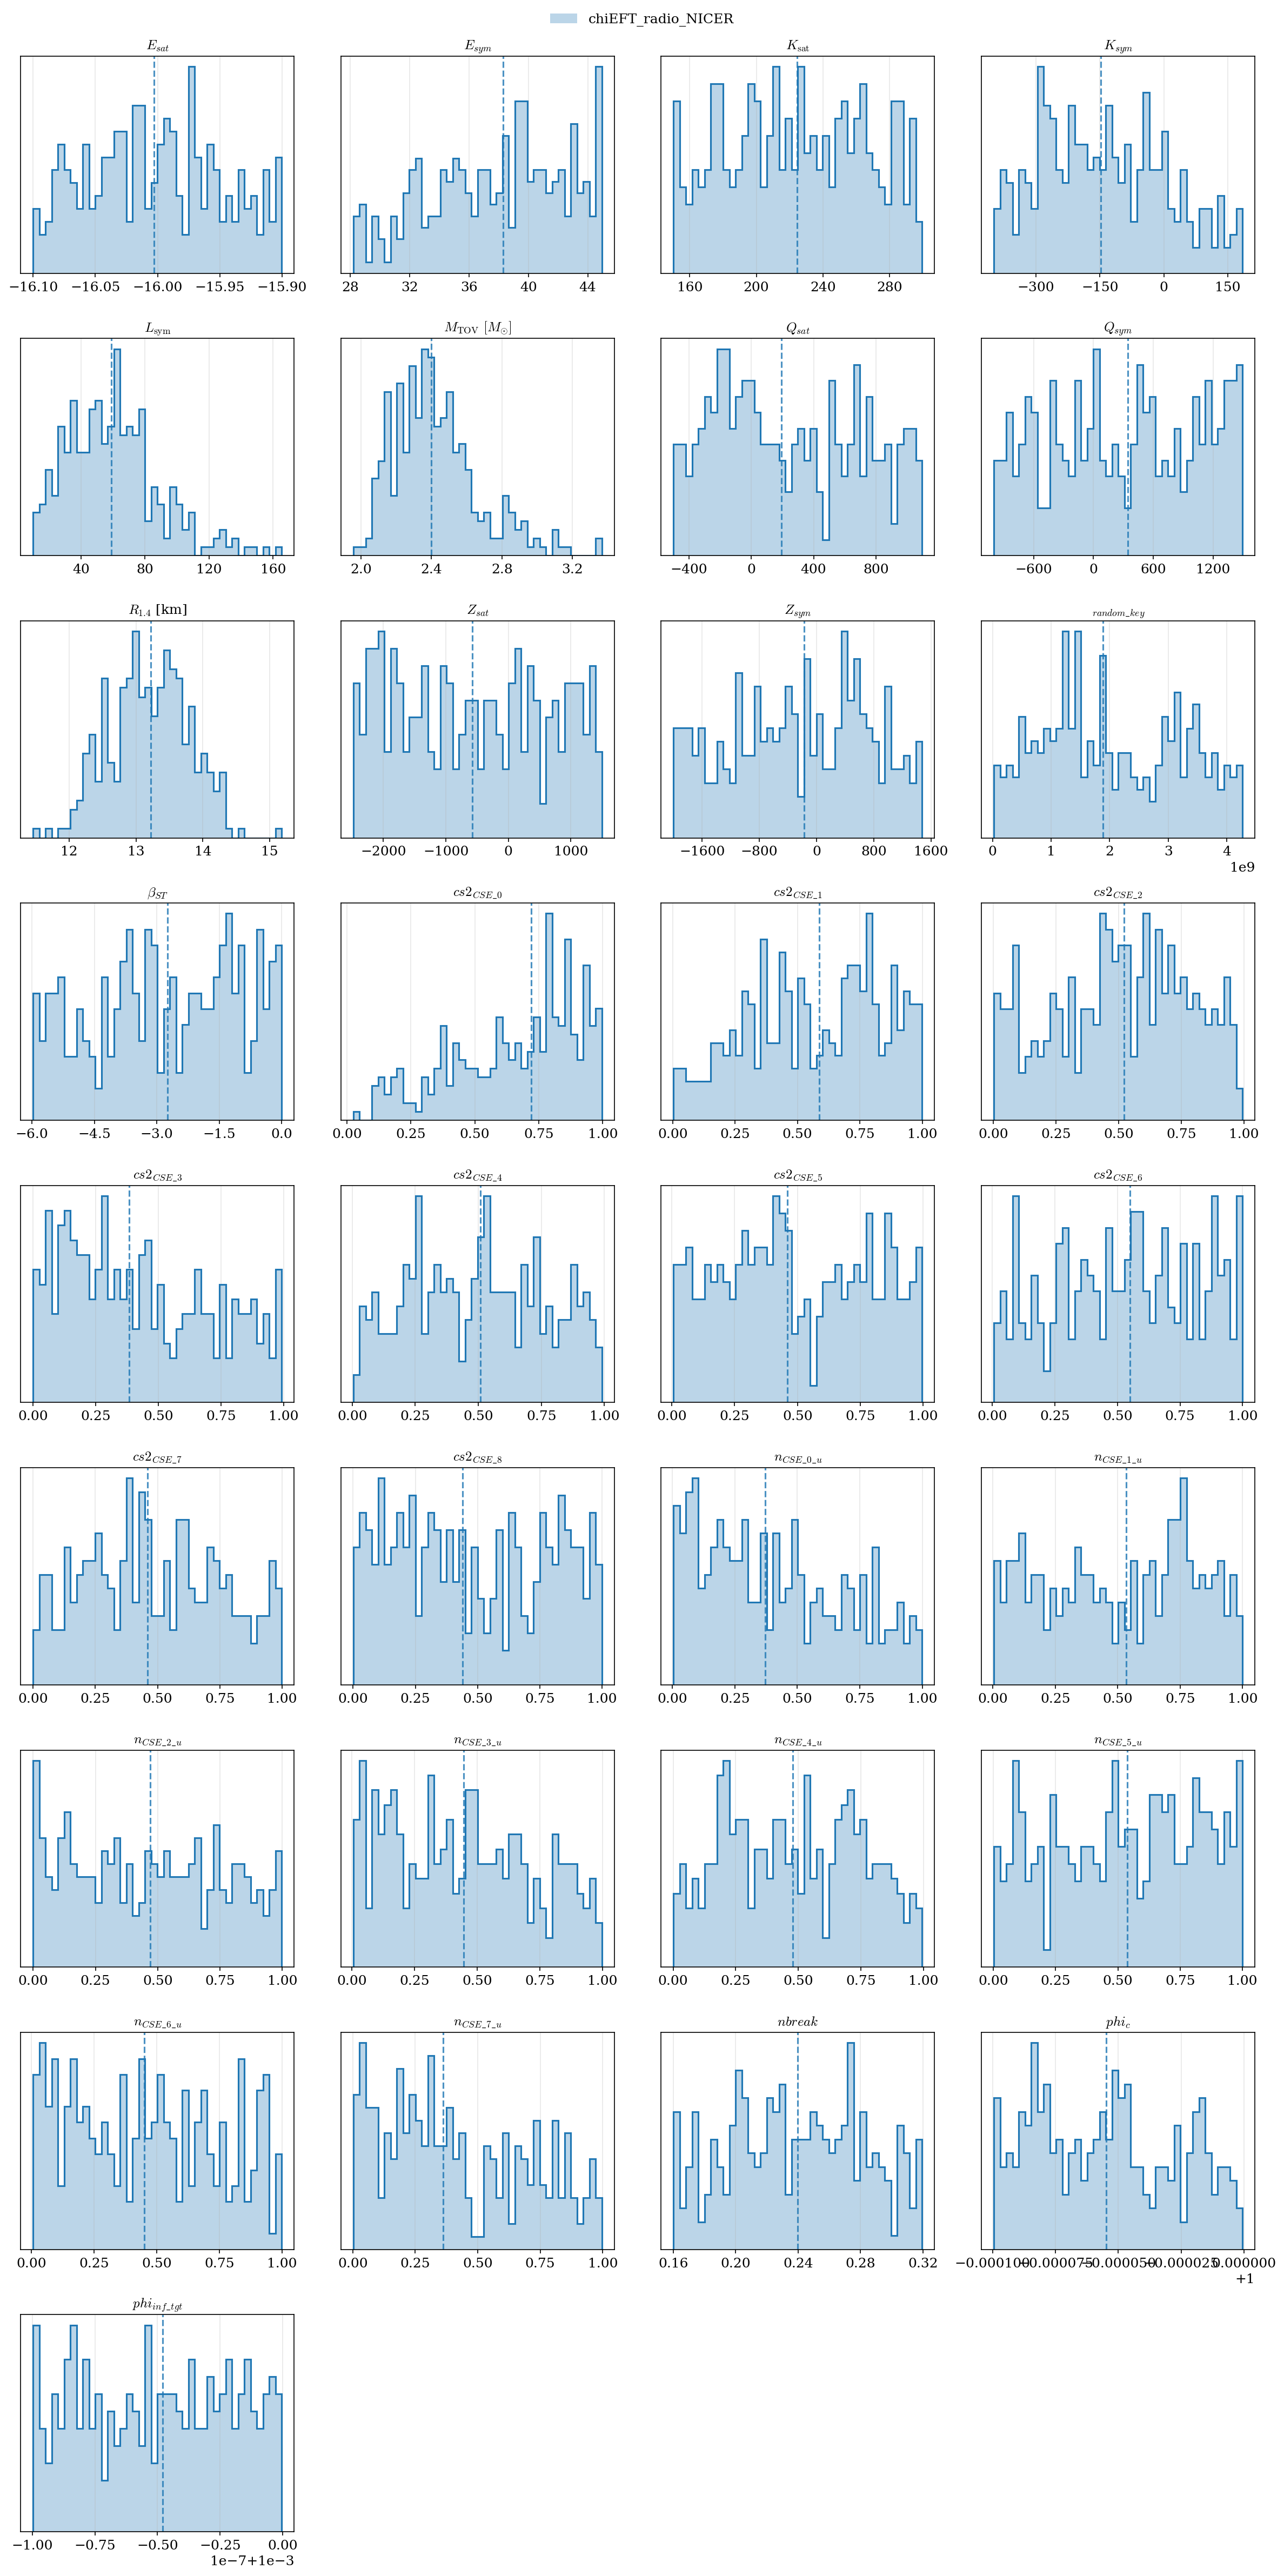

⏳ [Curves] Processing 1 inputs...


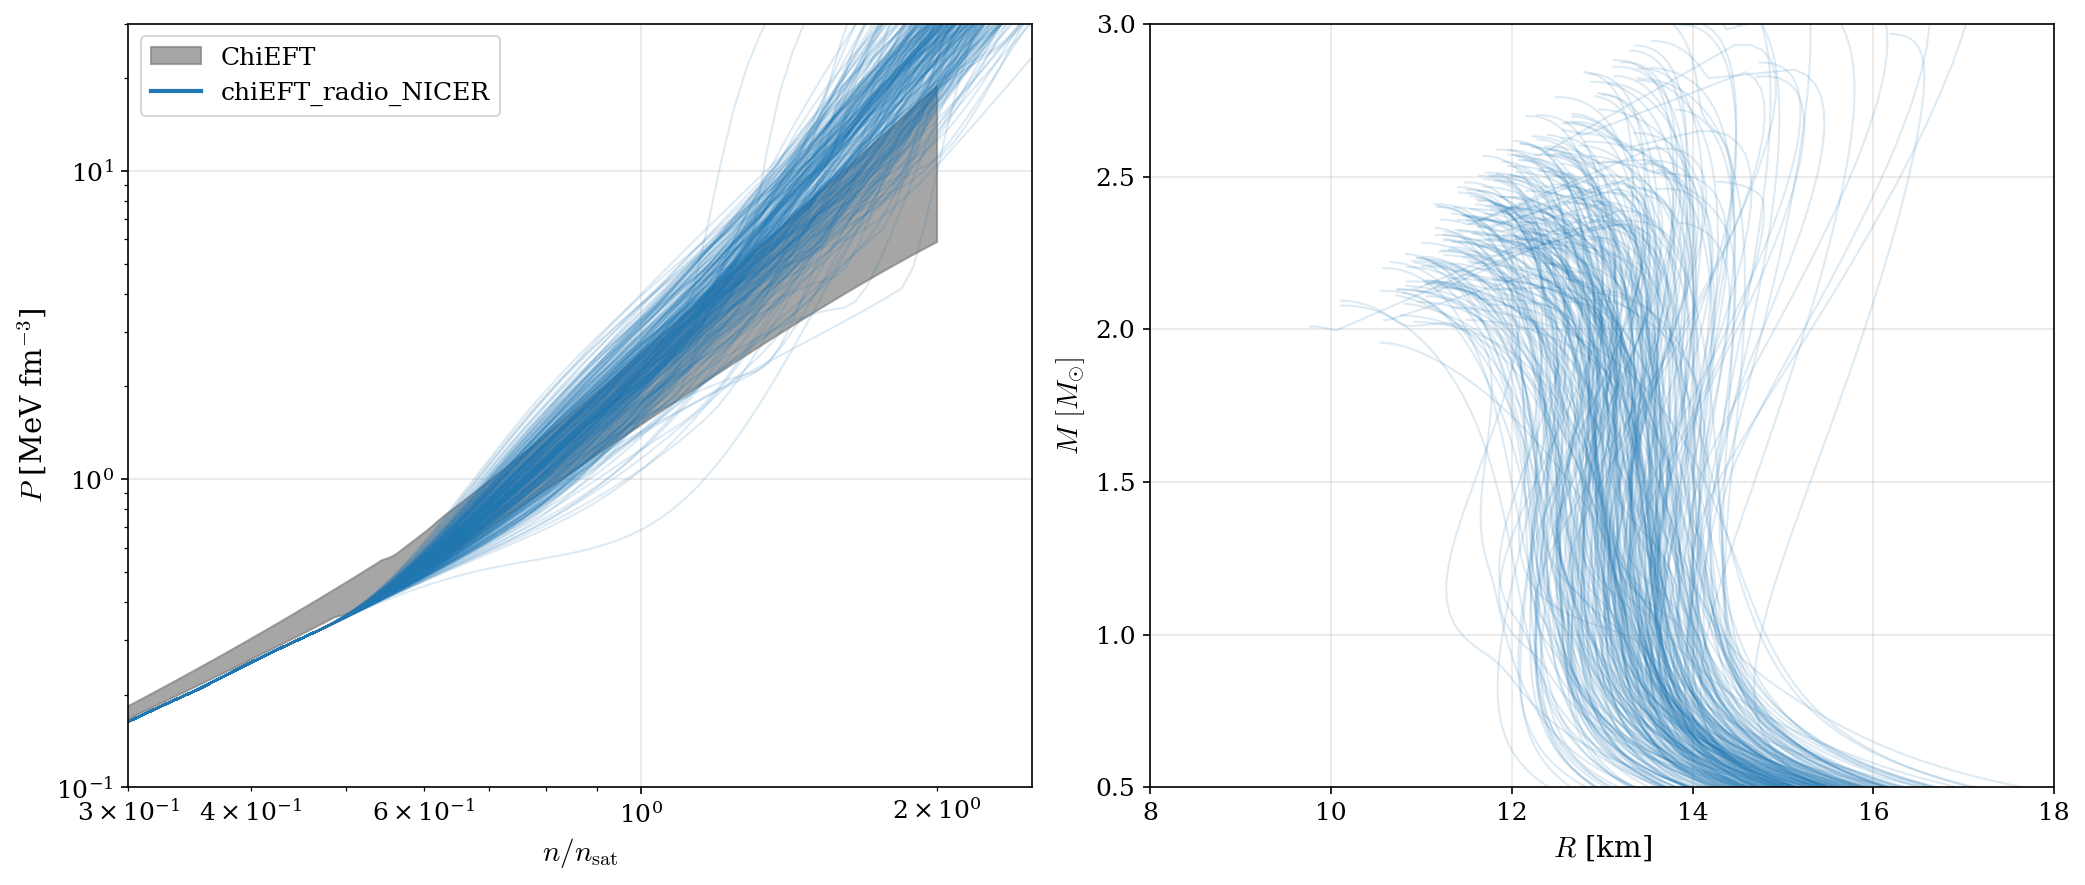

In [8]:
files_to_compare = [
    "st_smc_random_walk/chiEFT_radio_NICER/outdir/results.h5",
]

my_labels = [
    "chiEFT_radio_NICER",
]

# File 1: No filter
# File 2: Filter kappa < 1e7
# File 3: Filter chi2 < 5
# compare_eos_results(
#     "file1.h5",
#     ("file2.h5", {'kappa': (0, 1e7)}),
#     ("file3.h5", {'chi2': (0, 5)}),
#     labels=["Baseline", "Low Kappa", "Good Fit"]
# )

compare_eos_results(*files_to_compare, labels=my_labels)
plot_eos_curves(*files_to_compare, labels=my_labels)

  -> Derived M_TOV from mass sequences.
  -> Derived R_1.4 via interpolation.
🎨 Plotting corner for: ['M_TOV', 'R_1.4', 'beta_ST', 'E_sat', 'E_sym', 'L_sym', 'K_sat', 'K_sym', 'cs2_CSE_0']
✅ Corner plot saved to: ./corner_comparison.pdf


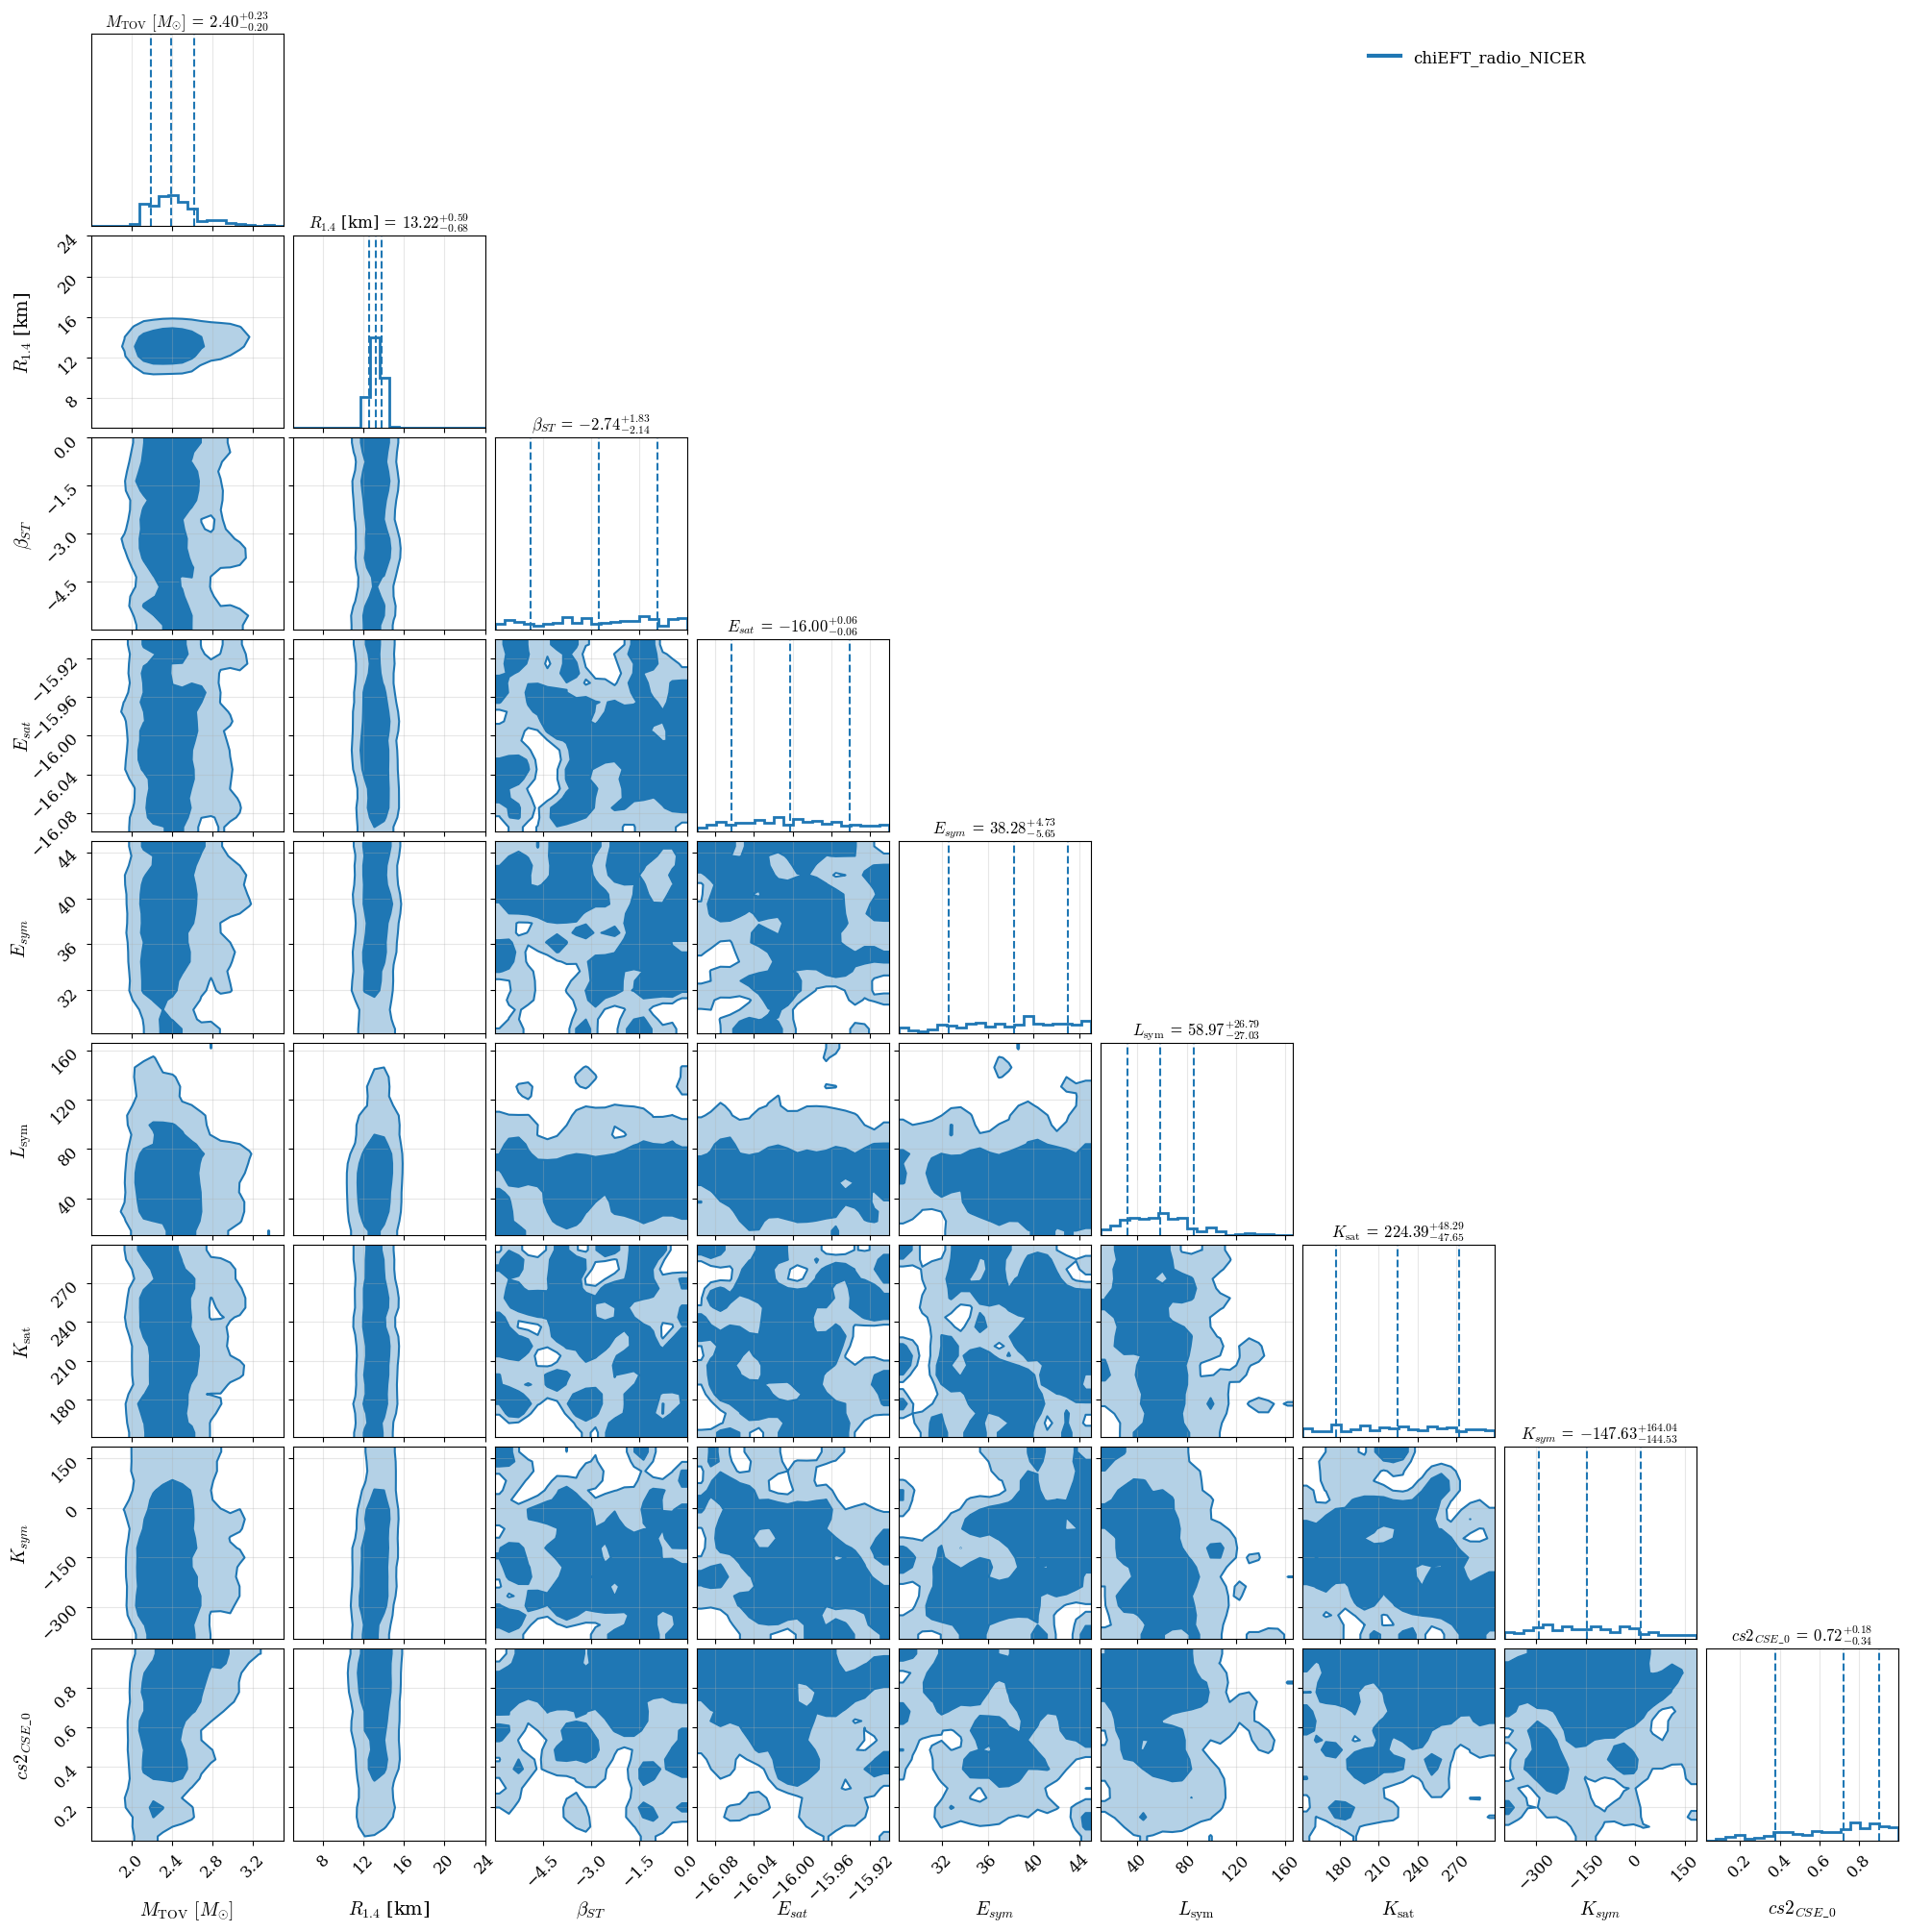

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import h5py
import os
import logging
import corner
from matplotlib.ticker import MaxNLocator

# ==============================================================================
#                               CONFIG & SETUP
# ==============================================================================

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("corner_maker")

PARAMS_CONFIG = {"USE_TEX": True}


def get_fancy_label(name):
    """Parses parameter names into LaTeX labels."""
    if not PARAMS_CONFIG["USE_TEX"]:
        return name

    MAPPING = {
        "M_TOV": r"$M_{\rm{TOV}}$ $[M_{\odot}]$",
        "R_1.4": r"$R_{1.4}$ [km]",
        "P_3nsat": r"$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]",
        "L_sym": r"$L_{\rm{sym}}$",
        "K_sat": r"$K_{\rm{sat}}$",
        "J_sym": r"$J_{\rm{sym}}$",
        "chi2": r"$\chi^2$",
        "log_prob": r"$\ln \mathcal{L}$",
    }
    if name in MAPPING:
        return MAPPING[name]

    if "lambda" in name.lower() and "tilde" in name.lower():
        return r"$\tilde{\Lambda}$"

    parts = name.split("_")
    base = parts[0]
    greek_letters = [
        "alpha",
        "beta",
        "gamma",
        "delta",
        "rho",
        "sigma",
        "kappa",
        "lambda",
        "epsilon",
        "zeta",
        "theta",
    ]
    if base in greek_letters:
        base = f"\\{base}"

    if len(parts) > 1:
        sub = r"\_".join(parts[1:])
        return f"${base}_{{{sub}}}$"

    return f"${base}$"


# ==============================================================================
#                                DATA LOADING
# ==============================================================================


def load_posterior_samples(filepath, requested_params=None):
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None, []

    data = {}
    with h5py.File(filepath, "r") as f:
        if "posterior" not in f:
            return None, []
        post = f["posterior"]

        # Priority mapping for sourcing data
        sources = [post.get("parameters", {}), post.get("derived_eos", post)]

        # 1. Load basic parameters
        all_keys_in_file = set()
        for src in sources:
            if hasattr(src, "keys"):
                all_keys_in_file.update(src.keys())

        keys_to_scan = requested_params if requested_params else all_keys_in_file

        for k in keys_to_scan:
            for src in sources:
                if hasattr(src, "keys") and k in src:
                    val = src[k][:]
                    if val.ndim == 1:
                        data[k] = val
                        break

        # 2. Derived Physics Logic (The "Feynman Step": Calculate what's missing)
        # Kita perlu masses dan radii buat M_TOV dan R_1.4
        eos_group = post.get("derived_eos", post)
        masses = None
        radii = None

        try:
            masses = eos_group.get("masses_EOS", eos_group.get("masses"))[:]
            radii = eos_group.get("radii_EOS", eos_group.get("radii"))[:]
        except:
            pass

        if masses is not None:
            # Derived: M_TOV
            if "M_TOV" in keys_to_scan and "M_TOV" not in data:
                data["M_TOV"] = np.max(masses, axis=1)
                logger.info("  -> Derived M_TOV from mass sequences.")

            # Derived: R_1.4 (Linear Interpolation)
            if "R_1.4" in keys_to_scan and "R_1.4" not in data and radii is not None:
                r14_list = []
                for m, r in zip(masses, radii):
                    # Sortir dulu biar np.interp nggak ngaco
                    idx = np.argsort(m)
                    m_s, r_s = m[idx], r[idx]
                    # Pastikan 1.4 Mo ada di dalam range
                    if m_s.min() <= 1.4 <= m_s.max():
                        r14_list.append(np.interp(1.4, m_s, r_s))
                    else:
                        r14_list.append(np.nan)
                data["R_1.4"] = np.array(r14_list)
                logger.info("  -> Derived R_1.4 via interpolation.")

    # Cleanup: Remove NaNs/Infs that could break corner plots
    final_keys = []
    if data:
        # Gunakan mask dari semua kolom buat mastiin barisnya konsisten
        valid_mask = np.ones(len(next(iter(data.values()))), dtype=bool)
        for k in data:
            valid_mask &= np.isfinite(data[k])

        for k in list(data.keys()):
            data[k] = data[k][valid_mask]
            final_keys.append(k)

    return data, final_keys


# ==============================================================================
#                                CORNER FUNCTION
# ==============================================================================


def make_comparison_corner(
    *file_paths,
    params=None,
    labels=None,
    limits=None,
    outdir=".",
    filename="corner_comparison.pdf",
):
    # 1. Setup Labels & Colors
    valid_paths = [p for p in file_paths if os.path.exists(p)]
    if not valid_paths:
        logger.error("💀 No valid files found.")
        return

    if labels is None:
        labels = [os.path.basename(p) for p in valid_paths]

    n_files = len(valid_paths)
    colors = (
        plt.cm.tab10(np.linspace(0, 1, 10))
        if n_files <= 10
        else plt.cm.turbo(np.linspace(0, 1, n_files))
    )

    # 2. Load Data
    loaded_datasets = []
    common_keys = None
    for fp in valid_paths:
        d, keys = load_posterior_samples(fp, requested_params=params)
        if d:
            loaded_datasets.append(d)
            if common_keys is None:
                common_keys = set(keys)
            else:
                common_keys.intersection_update(keys)

    if not loaded_datasets:
        logger.error("❌ No data loaded.")
        return

    plot_keys = params if params else sorted(list(common_keys))

    # 3. Global Ranges (X-Axis)
    global_ranges = []
    for k in plot_keys:
        if limits and k in limits:
            global_ranges.append(limits[k])
        else:
            combined_data = np.concatenate([d[k] for d in loaded_datasets])
            global_ranges.append((np.min(combined_data), np.max(combined_data)))

    logger.info(f"🎨 Plotting corner for: {plot_keys}")

    # 4. Plotting Loop
    fig = None
    fancy_labels = [get_fancy_label(k) for k in plot_keys]

    for i, data in enumerate(loaded_datasets):
        samples = np.column_stack([data[k] for k in plot_keys])

        # Normalisasi Manual (Weights)
        my_weights = np.ones(len(samples)) / len(samples)

        # Styling
        hist_settings = {
            "linewidth": 2
        }  # Density HARUS False/None disini, diurus weights

        if fig is None:
            fig = corner.corner(
                samples,
                labels=fancy_labels,
                color=colors[i],
                weights=my_weights,
                range=global_ranges,
                smooth=0.9,  # Sedikit smoothing biar ga bergerigi banget
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                hist_kwargs=hist_settings,
            )
        else:
            corner.corner(
                samples,
                fig=fig,
                color=colors[i],
                weights=my_weights,
                range=global_ranges,  # Wajib sama!
                smooth=0.9,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                hist_kwargs=hist_settings,
            )

    # ---------------------------------------------------------
    # 5. FIX Y-AXIS CLIPPING (Rescaling Diagonal Plots)
    # ---------------------------------------------------------
    ndim = len(plot_keys)
    # Reshape flat axes list to matrix
    axes_grid = np.array(fig.axes).reshape((ndim, ndim))

    for i in range(ndim):
        ax = axes_grid[i, i]  # Ambil subplot diagonal

        # Loop semua garis di subplot ini (histogram dari tiap dataset)
        max_heights = []
        for line in ax.lines:
            y_vals = line.get_ydata()
            if len(y_vals) > 0:
                max_heights.append(np.max(y_vals))

        if max_heights:
            # Cari puncak tertinggi dari semua dataset
            overall_max = np.max(max_heights)
            # Set limit baru + 10% padding
            ax.set_ylim(0, overall_max * 1.1)

    # 6. Legend
    legend_handles = []
    for i, lbl in enumerate(labels[: len(loaded_datasets)]):
        line = mlines.Line2D([], [], color=colors[i], label=lbl, linewidth=3)
        legend_handles.append(line)

    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.70, 0.98),  # Geser dikit biar pas
        fontsize=12,
        frameon=False,
    )

    # 7. Save
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    save_path = os.path.join(outdir, filename)
    fig.savefig(save_path, bbox_inches="tight")
    logger.info(f"✅ Corner plot saved to: {save_path}")


# ==============================================================================
#                                   USAGE
# ==============================================================================


if __name__ == "__main__":

    file2 = "st_smc_random_walk/prior/outdir/results.h5"
    file1 = "st_smc_random_walk/chiEFT_radio_NICER/outdir/results.h5"

    # Define custom limits for physics parameters
    my_limits = {
        "M_TOV": (1.6, 3.5),  # Zoom in on mass
        "R_1.4": (5.0, 24),  # Zoom in on radius
        "beta_ST": (-6, 0),  # Uncomment to limit L_sym
    }

    make_comparison_corner(
        file1,  # file2,
        params=[
            "M_TOV",
            "R_1.4",
            "beta_ST",
            "E_sat",
            "E_sym",
            "L_sym",
            "K_sat",
            "K_sym",
            "cs2_CSE_0",
        ],
        labels=["chiEFT_radio_NICER", "prior"],
        limits=my_limits,  # <--- Pass limits here
        # filename="corner_physics_zoomed.pdf"
    )

In [17]:
import h5py


def print_structure(name, obj):
    """
    Callback function to print the hierarchy of the HDF5 file.
    """
    # Create indentation based on depth
    depth = name.count("/")
    indent = "  " * depth

    if isinstance(obj, h5py.Group):
        print(f"{indent}📂 {name}/")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 {name}  {obj.shape}  ({obj.dtype})")


# Replace with your actual file path
FILENAME = "st_smc_random_walk/chiEFT_radio_NICER/outdir/results.h5"

print(f"--- Structure of {FILENAME} ---")
with h5py.File(FILENAME, "r") as f:
    f.visititems(print_structure)

--- Structure of st_smc_random_walk/chiEFT_radio_NICER/outdir/results.h5 ---
📂 histories/
  📄 histories/acceptance_history  (18,)  (float64)
  📄 histories/ess_history  (18,)  (float64)
  📄 histories/tempering_param_history  (18,)  (float64)
📂 metadata/
  📄 metadata/config  ()  (object)
📂 posterior/
  📂 posterior/derived_eos/
    📄 posterior/derived_eos/Lambdas_EOS  (300, 100)  (float64)
    📄 posterior/derived_eos/cs2  (300, 200)  (float64)
    📄 posterior/derived_eos/e  (300, 200)  (float64)
    📄 posterior/derived_eos/masses_EOS  (300, 100)  (float64)
    📄 posterior/derived_eos/n  (300, 200)  (float64)
    📄 posterior/derived_eos/p  (300, 200)  (float64)
    📄 posterior/derived_eos/radii_EOS  (300, 100)  (float64)
  📄 posterior/log_prob  (300,)  (float64)
  📂 posterior/parameters/
    📄 posterior/parameters/E_sat  (300,)  (float64)
    📄 posterior/parameters/E_sym  (300,)  (float64)
    📄 posterior/parameters/K_sat  (300,)  (float64)
    📄 posterior/parameters/K_sym  (300,)  (float6

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import h5py
import os
import logging
import corner
from matplotlib.ticker import MaxNLocator

# ==============================================================================
#                               CONFIG & SETUP
# ==============================================================================

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("corner_maker")

PARAMS_CONFIG = {"USE_TEX": True}


def get_fancy_label(name):
    """Parses parameter names into LaTeX labels."""
    if not PARAMS_CONFIG["USE_TEX"]:
        return name

    MAPPING = {
        "M_TOV": r"$M_{\rm{TOV}}$ $[M_{\odot}]$",
        "R_1.4": r"$R_{1.4}$ [km]",
        "P_3nsat": r"$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]",
        "L_sym": r"$L_{\rm{sym}}$",
        "K_sat": r"$K_{\rm{sat}}$",
        "J_sym": r"$J_{\rm{sym}}$",
        "chi2": r"$\chi^2$",
        "log_prob": r"$\ln \mathcal{L}$",
        "kappa_eibi": r"$\kappa$ [m$^2$]",
    }
    if name in MAPPING:
        return MAPPING[name]

    if "lambda" in name.lower() and "tilde" in name.lower():
        return r"$\tilde{\Lambda}$"

    parts = name.split("_")
    base = parts[0]
    greek_letters = [
        "alpha",
        "beta",
        "gamma",
        "delta",
        "rho",
        "sigma",
        "kappa",
        "lambda",
        "epsilon",
        "zeta",
        "theta",
    ]
    if base in greek_letters:
        base = f"\\{base}"

    if len(parts) > 1:
        sub = r"\_".join(parts[1:])
        return f"${base}_{{{sub}}}$"

    return f"${base}$"


# ==============================================================================
#                                DATA LOADING
# ==============================================================================


def load_posterior_samples(filepath, requested_params=None):
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None, []

    data = {}
    with h5py.File(filepath, "r") as f:
        if "posterior" not in f:
            return None, []
        post = f["posterior"]

        sources = [post.get("parameters", {}), post.get("derived_eos", post)]

        all_keys_in_file = set()
        for src in sources:
            if hasattr(src, "keys"):
                all_keys_in_file.update(src.keys())

        keys_to_scan = requested_params if requested_params else all_keys_in_file

        for k in keys_to_scan:
            for src in sources:
                if hasattr(src, "keys") and k in src:
                    val = src[k][:]
                    if val.ndim == 1:
                        data[k] = val
                        break

        # Derived Physics Logic
        eos_group = post.get("derived_eos", post)
        masses = None
        radii = None

        try:
            masses = eos_group.get("masses_EOS", eos_group.get("masses"))[:]
            radii = eos_group.get("radii_EOS", eos_group.get("radii"))[:]
        except:
            pass

        if masses is not None:
            if "M_TOV" in keys_to_scan and "M_TOV" not in data:
                data["M_TOV"] = np.max(masses, axis=1)
                logger.info("  -> Derived M_TOV from mass sequences.")

            if "R_1.4" in keys_to_scan and "R_1.4" not in data and radii is not None:
                r14_list = []
                for m, r in zip(masses, radii):
                    idx = np.argsort(m)
                    m_s, r_s = m[idx], r[idx]
                    if m_s.min() <= 1.4 <= m_s.max():
                        r14_list.append(np.interp(1.4, m_s, r_s))
                    else:
                        r14_list.append(np.nan)
                data["R_1.4"] = np.array(r14_list)
                logger.info("  -> Derived R_1.4 via interpolation.")

    final_keys = []
    if data:
        valid_mask = np.ones(len(next(iter(data.values()))), dtype=bool)
        for k in data:
            valid_mask &= np.isfinite(data[k])

        for k in list(data.keys()):
            data[k] = data[k][valid_mask]
            final_keys.append(k)

    return data, final_keys


# ==============================================================================
#                                CORNER FUNCTION
# ==============================================================================


def make_comparison_corner(
    *file_paths,
    params=None,
    labels=None,
    limits=None,
    outdir=".",
    filename="corner_comparison.pdf",
):
    # 1. Setup Labels & Colors
    valid_paths = [p for p in file_paths if os.path.exists(p)]
    if not valid_paths:
        logger.error("💀 No valid files found.")
        return

    if labels is None:
        labels = [os.path.basename(p) for p in valid_paths]

    n_files = len(valid_paths)
    colors = (
        plt.cm.tab10(np.linspace(0, 1, 10))
        if n_files <= 10
        else plt.cm.turbo(np.linspace(0, 1, n_files))
    )

    # 2. Load Data
    loaded_datasets = []
    common_keys = None
    for fp in valid_paths:
        d, keys = load_posterior_samples(fp, requested_params=params)
        if d:
            loaded_datasets.append(d)
            if common_keys is None:
                common_keys = set(keys)
            else:
                common_keys.intersection_update(keys)

    if not loaded_datasets:
        logger.error("❌ No data loaded.")
        return

    plot_keys = params if params else sorted(list(common_keys))

    # 3. Global Ranges (PENTING BIAR GA KEPOTONG)
    global_ranges = []
    for k in plot_keys:
        if limits and k in limits:
            global_ranges.append(limits[k])
        else:
            combined_data = np.concatenate([d[k] for d in loaded_datasets])
            global_ranges.append((np.min(combined_data), np.max(combined_data)))

    logger.info(f"🎨 Plotting corner for: {plot_keys}")

    # 4. Plotting Loop
    fig = None
    fancy_labels = [get_fancy_label(k) for k in plot_keys]
    ndim = len(plot_keys)

    for i, data in enumerate(loaded_datasets):
        samples = np.column_stack([data[k] for k in plot_keys])
        color = colors[i]

        # --- A. Setup Figure & 2D Contours ---
        # Kita pakai weights untuk normalisasi histogram bawaan (meskipun invisible)
        # Ini biar corner.py gak bingung ngitung y-axisnya
        # my_weights = np.ones(len(samples)) / len(samples)

        if fig is None:
            fig = corner.corner(
                samples,
                labels=fancy_labels,
                color=color,
                # weights=my_weights,
                range=global_ranges,
                smooth=1.0,
                smooth1d=1.0,
                quantiles=None,
                show_titles=False,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                # TRIK: Bikin histogram default jadi invisible (alpha=0)
                # JANGAN PAKAI 'density': True DISINI
                hist_kwargs={"alpha": 0.0, "linewidth": 0},
            )
        else:
            corner.corner(
                samples,
                fig=fig,
                color=color,
                # weights=my_weights,
                range=global_ranges,
                smooth=1.0,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                # TRIK SAMA: Invisible
                hist_kwargs={"alpha": 0.0, "linewidth": 0},
            )

        # --- B. CUSTOM 1D HISTOGRAMS (Gaya Unified EOS) ---
        axes = np.array(fig.axes).reshape((ndim, ndim))

        for d_idx in range(ndim):
            ax = axes[d_idx, d_idx]
            d_col = samples[:, d_idx]

            # HITUNG WEIGHTS MANUAL
            # Ini memastikan normalisasi didasarkan pada TOTAL data, bukan data yang terlihat saja.
            # Jadi kalau di-zoom, grafik tidak berubah bentuk/tinggi.
            weights = np.ones_like(d_col) / len(d_col)

            # 1. Filled Histogram
            # Ganti density=True menjadi density=False, dan masukkan weights
            ax.hist(
                d_col,
                bins=40,
                range=global_ranges[d_idx],
                density=False,
                weights=weights,  # <--- PERUBAHAN DISINI
                color=color,
                alpha=0.3,
            )

            # 2. Step Histogram
            ax.hist(
                d_col,
                bins=40,
                range=global_ranges[d_idx],
                density=False,
                weights=weights,  # <--- PERUBAHAN DISINI
                color=color,
                histtype="step",
                linewidth=1.5,
            )

            # 3. Median Line & Styling (Tetap sama)
            ax.axvline(np.median(d_col), color=color, linestyle="--", alpha=0.8)
            ax.set_yticks([])
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    # 5. FIX Y-AXIS CLIPPING (Updated Logic for Weights)
    axes_grid = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        ax = axes_grid[i, i]
        all_hists_max = 0
        for dataset in loaded_datasets:
            d_col = dataset[plot_keys[i]]
            # Hitung histogram helper juga pakai weights
            w = np.ones_like(d_col) / len(d_col)
            h, _ = np.histogram(
                d_col, bins=40, range=global_ranges[i], weights=w, density=False
            )
            all_hists_max = max(all_hists_max, np.max(h))
        ax.set_ylim(0, all_hists_max * 1.1)

    # 6. Legend
    legend_handles = []
    for i, lbl in enumerate(labels[: len(loaded_datasets)]):
        line = mlines.Line2D([], [], color=colors[i], label=lbl, linewidth=3)
        legend_handles.append(line)

    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.70, 0.98),
        fontsize=12,
        frameon=False,
    )

    # 7. Save
    if not os.path.exists(outdir):
        os.makedirs(outdir)
    save_path = os.path.join(outdir, filename)
    fig.savefig(save_path, bbox_inches="tight")
    logger.info(f"✅ Corner plot saved to: {save_path}")


# ==============================================================================
#                                   USAGE
# ==============================================================================


if __name__ == "__main__":

    file1 = "smc_random_walk_eibi/prior/outdir/results.h5"
    file2 = "smc_random_walk_eibi/chiEFT_radio_GW170817_NICER/outdir/results.h5"

    my_limits = {"M_TOV": (1.0, 5), "R_1.4": (5.0, 44), "kappa_eibi": (-3e7, 3e7)}

    make_comparison_corner(
        file1,
        file2,
        params=["M_TOV", "R_1.4", "kappa_eibi"],
        labels=["Prior", "chiEFT+radio+GW170817+NICER"],
        limits=my_limits,
    )

💀 No valid files found.
